# تحلیل و پیش‌بینی امید به زندگی

در این نوت‌بوک داده‌های مربوط به شاخص‌های سلامت، اقتصادی و اجتماعی کشورها بررسی می‌شود تا رابطه‌ی آن‌ها با ستون `Life expectancy` تحلیل شود. روند کلی کار شامل خواندن داده، بررسی اولیه، پاک‌سازی، مدیریت مقادیر گمشده، رسم نمودارهای اکتشافی، ساخت ویژگی‌ها و آموزش چند مدل رگرسیونی است.

### وارد کردن کتابخانه‌ها

در این بخش کتابخانه‌های اصلی پروژه وارد می‌شوند:

- `pandas` و `numpy` برای مدیریت داده‌ها و محاسبات عددی
- `matplotlib` و `seaborn` برای رسم نمودارها
- ابزارهای `sklearn` برای تقسیم داده، ساخت مدل رگرسیون، ویژگی‌های چندجمله‌ای و معیارهای ارزیابی


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split as tts
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score
from sklearn.preprocessing import PolynomialFeatures 

### خواندن فایل داده

فایل `Life_Expectancy_Data_PySHUAB.csv` با استفاده از `pandas` خوانده می‌شود و در متغیر `df` قرار می‌گیرد. از این مرحله به بعد تمام بررسی‌ها و مدل‌سازی‌ها بر پایه‌ی همین داده انجام می‌شوند.


In [2]:
df = pd.read_csv("Life_Expectancy_Data_PySHUAB.csv")

### آمار توصیفی ستون‌های عددی

با `describe(include="number")` خلاصه‌ای از ستون‌های عددی می‌گیریم. این خروجی برای دیدن میانگین، انحراف معیار، کمینه، بیشینه و چارک‌ها استفاده می‌شود و کمک می‌کند بازه‌ی مقادیر هر ویژگی را بهتر بشناسیم.


In [3]:
df.describe(include="number")

,Year,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling,Life expectancy
count,2236.000000,2236.000000,2236.000000,2099.000000,2236.000000,1907.000000,2236.000000,2236.000000,2236.000000,2228.000000,2096.000000,2236.000000,2236.000000,2222.000000,2.236000e+03,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000
mean,2007.489267,168.421288,34.183363,4.710886,845.310698,79.167278,2581.139088,37.363998,47.432021,81.351885,6.005582,81.401610,2.068068,6704.723290,1.288122e+07,4.891011,4.952057,0.624345,11.978623,68.830680
std,4.607685,128.951738,133.111742,4.068392,2186.200334,24.726199,11670.127732,19.883941,180.934025,23.909969,2.371572,23.974813,5.703550,13646.670387,6.165902e+07,4.681972,4.779457,0.206170,3.319843,9.828591
min,2000.000000,1.000000,0.000000,0.010000,0.000000,2.000000,0.000000,1.400000,0.000000,3.000000,0.370000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000,36.300000
25%,2003.000000,71.000000,0.000000,0.915000,21.246112,75.000000,0.000000,18.700000,1.000000,75.750000,4.377500,77.000000,0.100000,429.670960,1.984078e+05,1.500000,1.500000,0.486000,10.000000,62.500000
50%,2007.000000,145.000000,3.000000,4.050000,96.186053,88.000000,18.000000,41.900000,4.000000,92.000000,5.870000,92.000000,0.100000,1521.980960,1.396804e+06,2.900000,3.000000,0.666000,12.200000,71.600000
75%,2011.000000,233.250000,22.000000,7.575000,501.950334,96.000000,430.250000,55.800000,30.000000,97.000000,7.692500,96.000000,1.100000,5193.357942,7.426746e+06,7.400000,7.400000,0.770250,14.400000,75.500000
max,2015.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,77.600000,2500.000000,99.000000,14.390000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000,89.000000


### آمار توصیفی ستون‌های متنی

در این بخش ستون‌های غیرعددی یا متنی بررسی می‌شوند. خروجی شامل تعداد مقدارها، تعداد مقدارهای یکتا، پرتکرارترین مقدار و تعداد تکرار آن است؛ برای ستون‌هایی مثل `Country` و `Status` این اطلاعات مفید است.


In [4]:
df.describe(include="object")


C:\Users\Mahdi\AppData\Local\Temp\ipykernel_13504\3764884355.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,Country,Status
count,2236,2236
unique,140,2
top,Afghanistan,Developing
freq,16,1820


### بررسی داده‌های گمشده

قبل از پاک‌سازی و مدل‌سازی باید بدانیم هر ستون چند مقدار خالی دارد. خروجی این سلول تعداد مقدارهای گمشده را برای هر ستون نشان می‌دهد و مشخص می‌کند کدام ستون‌ها نیاز به حذف یا جایگزینی مقدار دارند.


In [5]:
df.isna().sum()

Country                              0
Year                                 0
Status                               0
Adult Mortality                      0
infant deaths                        0
Alcohol                            137
percentage expenditure               0
Hepatitis B                        329
Measles                              0
 BMI                                 0
under-five deaths                    0
Polio                                8
Total expenditure                  140
Diphtheria                           0
 HIV/AIDS                            0
GDP                                 14
Population                           0
 thinness  1-19 years                0
 thinness 5-9 years                  0
Income composition of resources      0
Schooling                            0
Life expectancy                      0
dtype: int64

### ساخت کپی و حذف ردیف‌های ناقص

برای تحلیل تصویری اولیه یک نسخه‌ی جدا از داده با نام `df_vis` ساخته می‌شود. سپس ردیف‌هایی که حداقل یک مقدار گمشده دارند حذف می‌شوند تا نمودارهای پراکندگی و همبستگی روی داده‌های کامل رسم شوند.

این کار فقط برای بخش بصری‌سازی انجام می‌شود؛ در ادامه برای مدل‌سازی، روش دقیق‌تری برای مدیریت مقادیر گمشده استفاده خواهد شد.


In [6]:
df_vis = df.copy()

df_vis.dropna(axis=0 , inplace=True)

### نمایش داده‌های پاک‌سازی‌شده

در این سلول نسخه‌ی بدون مقدار گمشده نمایش داده می‌شود تا مطمئن شویم داده برای مرحله‌ی رسم نمودار آماده است و ساختار کلی جدول تغییر ناخواسته‌ای نداشته است.


In [7]:
df_vis

,Country,Year,Status,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,...,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling,Life expectancy
0,Afghanistan,2015,Developing,263,62,0.01,71.279624,65.0,1154,19.1,...,8.16,65,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1,65.0
1,Afghanistan,2014,Developing,271,64,0.01,73.523582,62.0,492,18.6,...,8.18,62,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0,59.9
2,Afghanistan,2013,Developing,268,66,0.01,73.219243,64.0,430,18.1,...,8.13,64,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9,59.9
3,Afghanistan,2012,Developing,272,69,0.01,78.184215,67.0,2787,17.6,...,8.52,67,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8,59.5
4,Afghanistan,2011,Developing,275,71,0.01,7.097109,68.0,3013,17.2,...,7.87,68,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5,59.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2231,Zimbabwe,2004,Developing,723,27,4.36,0.000000,68.0,31,27.1,...,7.13,65,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2,44.3
2232,Zimbabwe,2003,Developing,715,26,4.06,0.000000,7.0,998,26.7,...,6.52,68,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5,44.5
2233,Zimbabwe,2002,Developing,73,25,4.43,0.000000,73.0,304,26.3,...,6.53,71,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0,44.8
2234,Zimbabwe,2001,Developing,686,25,1.72,0.000000,76.0,529,25.9,...,6.16,75,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8,45.3


### بررسی دوباره داده‌های گمشده

پس از حذف ردیف‌های ناقص، دوباره تعداد مقدارهای گمشده بررسی می‌شود. انتظار داریم همه‌ی ستون‌ها مقدار صفر داشته باشند، چون در این نسخه فقط ردیف‌های کامل نگه داشته شده‌اند.


In [8]:
df_vis.isna().sum()

Country                            0
Year                               0
Status                             0
Adult Mortality                    0
infant deaths                      0
Alcohol                            0
percentage expenditure             0
Hepatitis B                        0
Measles                            0
 BMI                               0
under-five deaths                  0
Polio                              0
Total expenditure                  0
Diphtheria                         0
 HIV/AIDS                          0
GDP                                0
Population                         0
 thinness  1-19 years              0
 thinness 5-9 years                0
Income composition of resources    0
Schooling                          0
Life expectancy                    0
dtype: int64

### حذف ستون‌های غیرعددی

برای رسم نمودارهای عددی و محاسبه‌ی همبستگی، ستون‌های `Country`، `Year` و `Status` از نسخه‌ی `df_vis` حذف می‌شوند. این ستون‌ها یا متنی هستند یا برای این بخش از تحلیل تصویری مستقیم استفاده نمی‌شوند.


In [9]:
df_vis.drop(["Country" , "Year" , "Status"] , axis=1 , inplace=True)

### نمایش داده‌های آماده نمودار

بعد از حذف ستون‌های غیرعددی، جدول نهایی مخصوص بصری‌سازی نمایش داده می‌شود. در این مرحله همه‌ی ستون‌های باقی‌مانده عددی هستند و می‌توانند در نمودارهای پراکندگی و نقشه‌ی همبستگی استفاده شوند.


In [10]:
df_vis

,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling,Life expectancy
0,263,62,0.01,71.279624,65.0,1154,19.1,83,6.0,8.16,65,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1,65.0
1,271,64,0.01,73.523582,62.0,492,18.6,86,58.0,8.18,62,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0,59.9
2,268,66,0.01,73.219243,64.0,430,18.1,89,62.0,8.13,64,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9,59.9
3,272,69,0.01,78.184215,67.0,2787,17.6,93,67.0,8.52,67,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8,59.5
4,275,71,0.01,7.097109,68.0,3013,17.2,97,68.0,7.87,68,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5,59.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2231,723,27,4.36,0.000000,68.0,31,27.1,42,67.0,7.13,65,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2,44.3
2232,715,26,4.06,0.000000,7.0,998,26.7,41,7.0,6.52,68,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5,44.5
2233,73,25,4.43,0.000000,73.0,304,26.3,40,73.0,6.53,71,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0,44.8
2234,686,25,1.72,0.000000,76.0,529,25.9,39,76.0,6.16,75,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8,45.3


### رسم نمودار پراکندگی

در این بخش برای هر ویژگی عددی یک نمودار پراکندگی در برابر `Life expectancy` رسم می‌شود. این نمودارها کمک می‌کنند رابطه‌ی تقریبی هر متغیر با امید به زندگی دیده شود؛ برای مثال می‌توان روندهای مثبت، منفی، غیرخطی یا نقاط پرت را تشخیص داد.


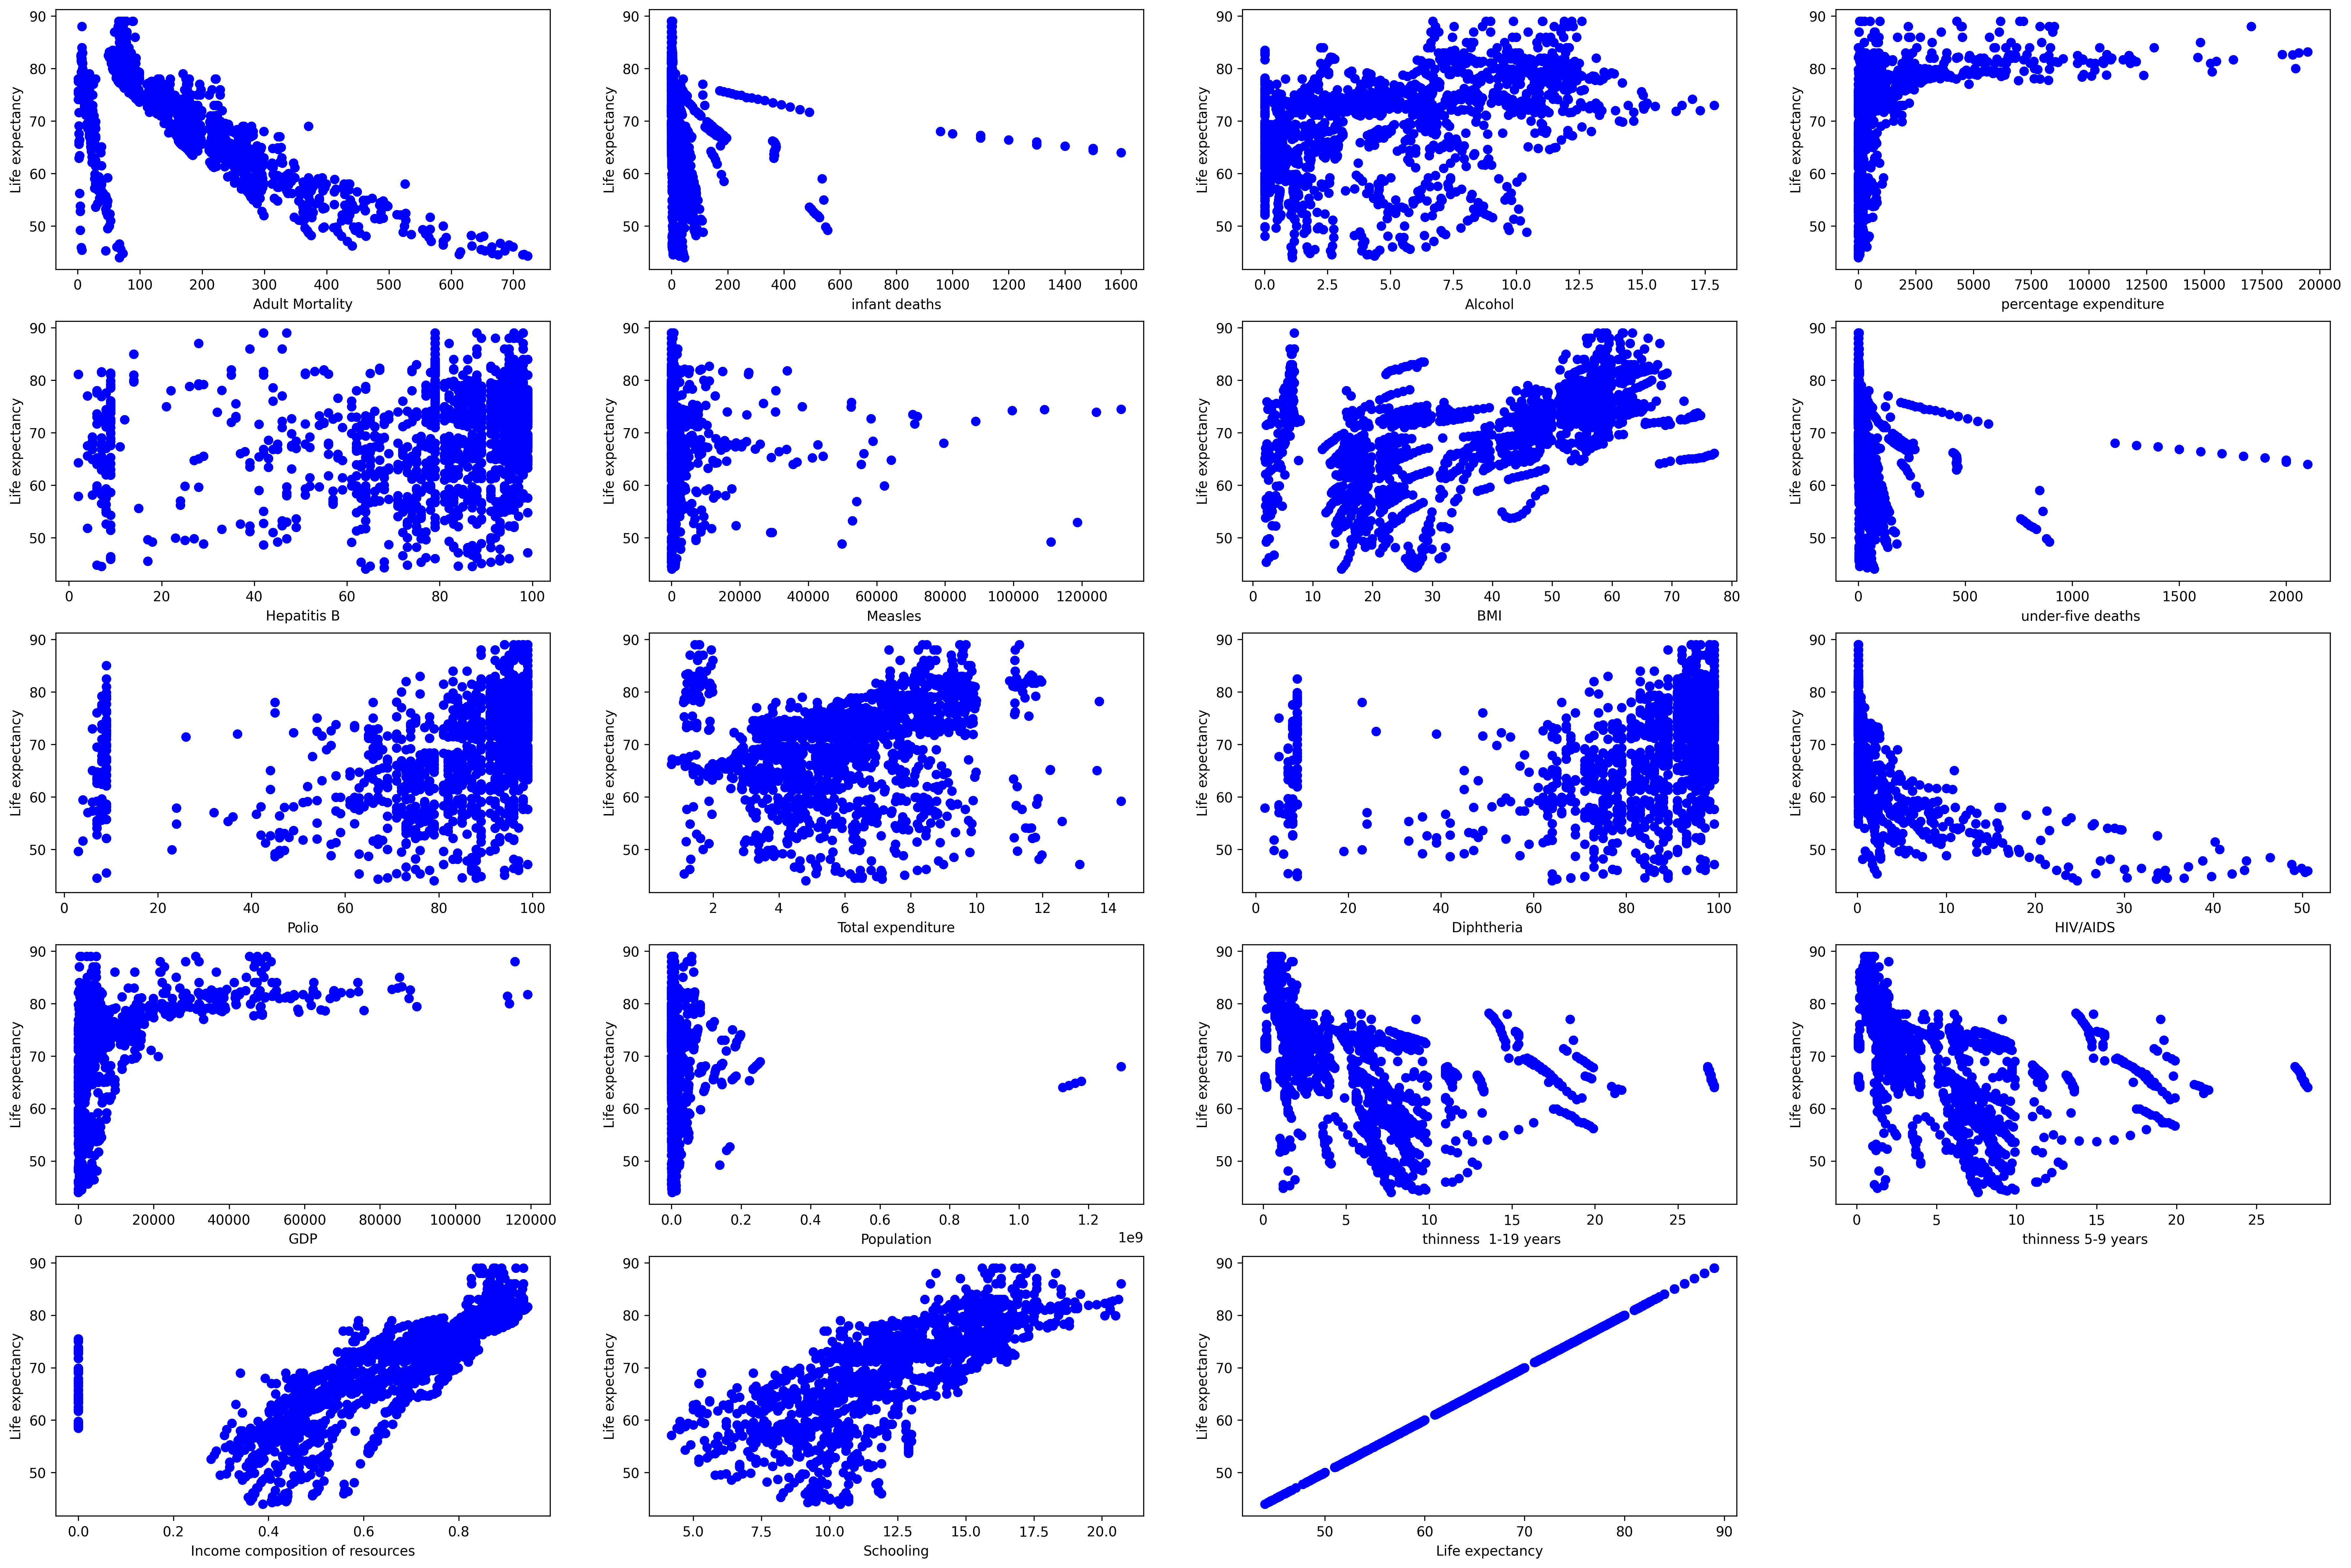

In [11]:
fig = plt.figure(figsize=(30 , 20) , dpi=300)

for i in range(1 , 20):
    plt.subplot(5 , 4 , i)
    plt.scatter(df_vis.iloc[: , i-1] , df_vis["Life expectancy"] , color = "blue")
    plt.xlabel(df_vis.columns[i-1])
    plt.ylabel("Life expectancy")

plt.show()
    

### رسم نقشه همبستگی

نقشه‌ی همبستگی شدت رابطه‌ی خطی بین ستون‌های عددی را نشان می‌دهد. مقدارهای نزدیک به `1` نشان‌دهنده‌ی رابطه‌ی مثبت قوی، مقدارهای نزدیک به `-1` نشان‌دهنده‌ی رابطه‌ی منفی قوی و مقدارهای نزدیک به `0` نشان‌دهنده‌ی رابطه‌ی خطی ضعیف هستند.

این نمودار برای انتخاب ویژگی‌ها و فهمیدن ارتباط بین متغیرها قبل از مدل‌سازی مفید است.


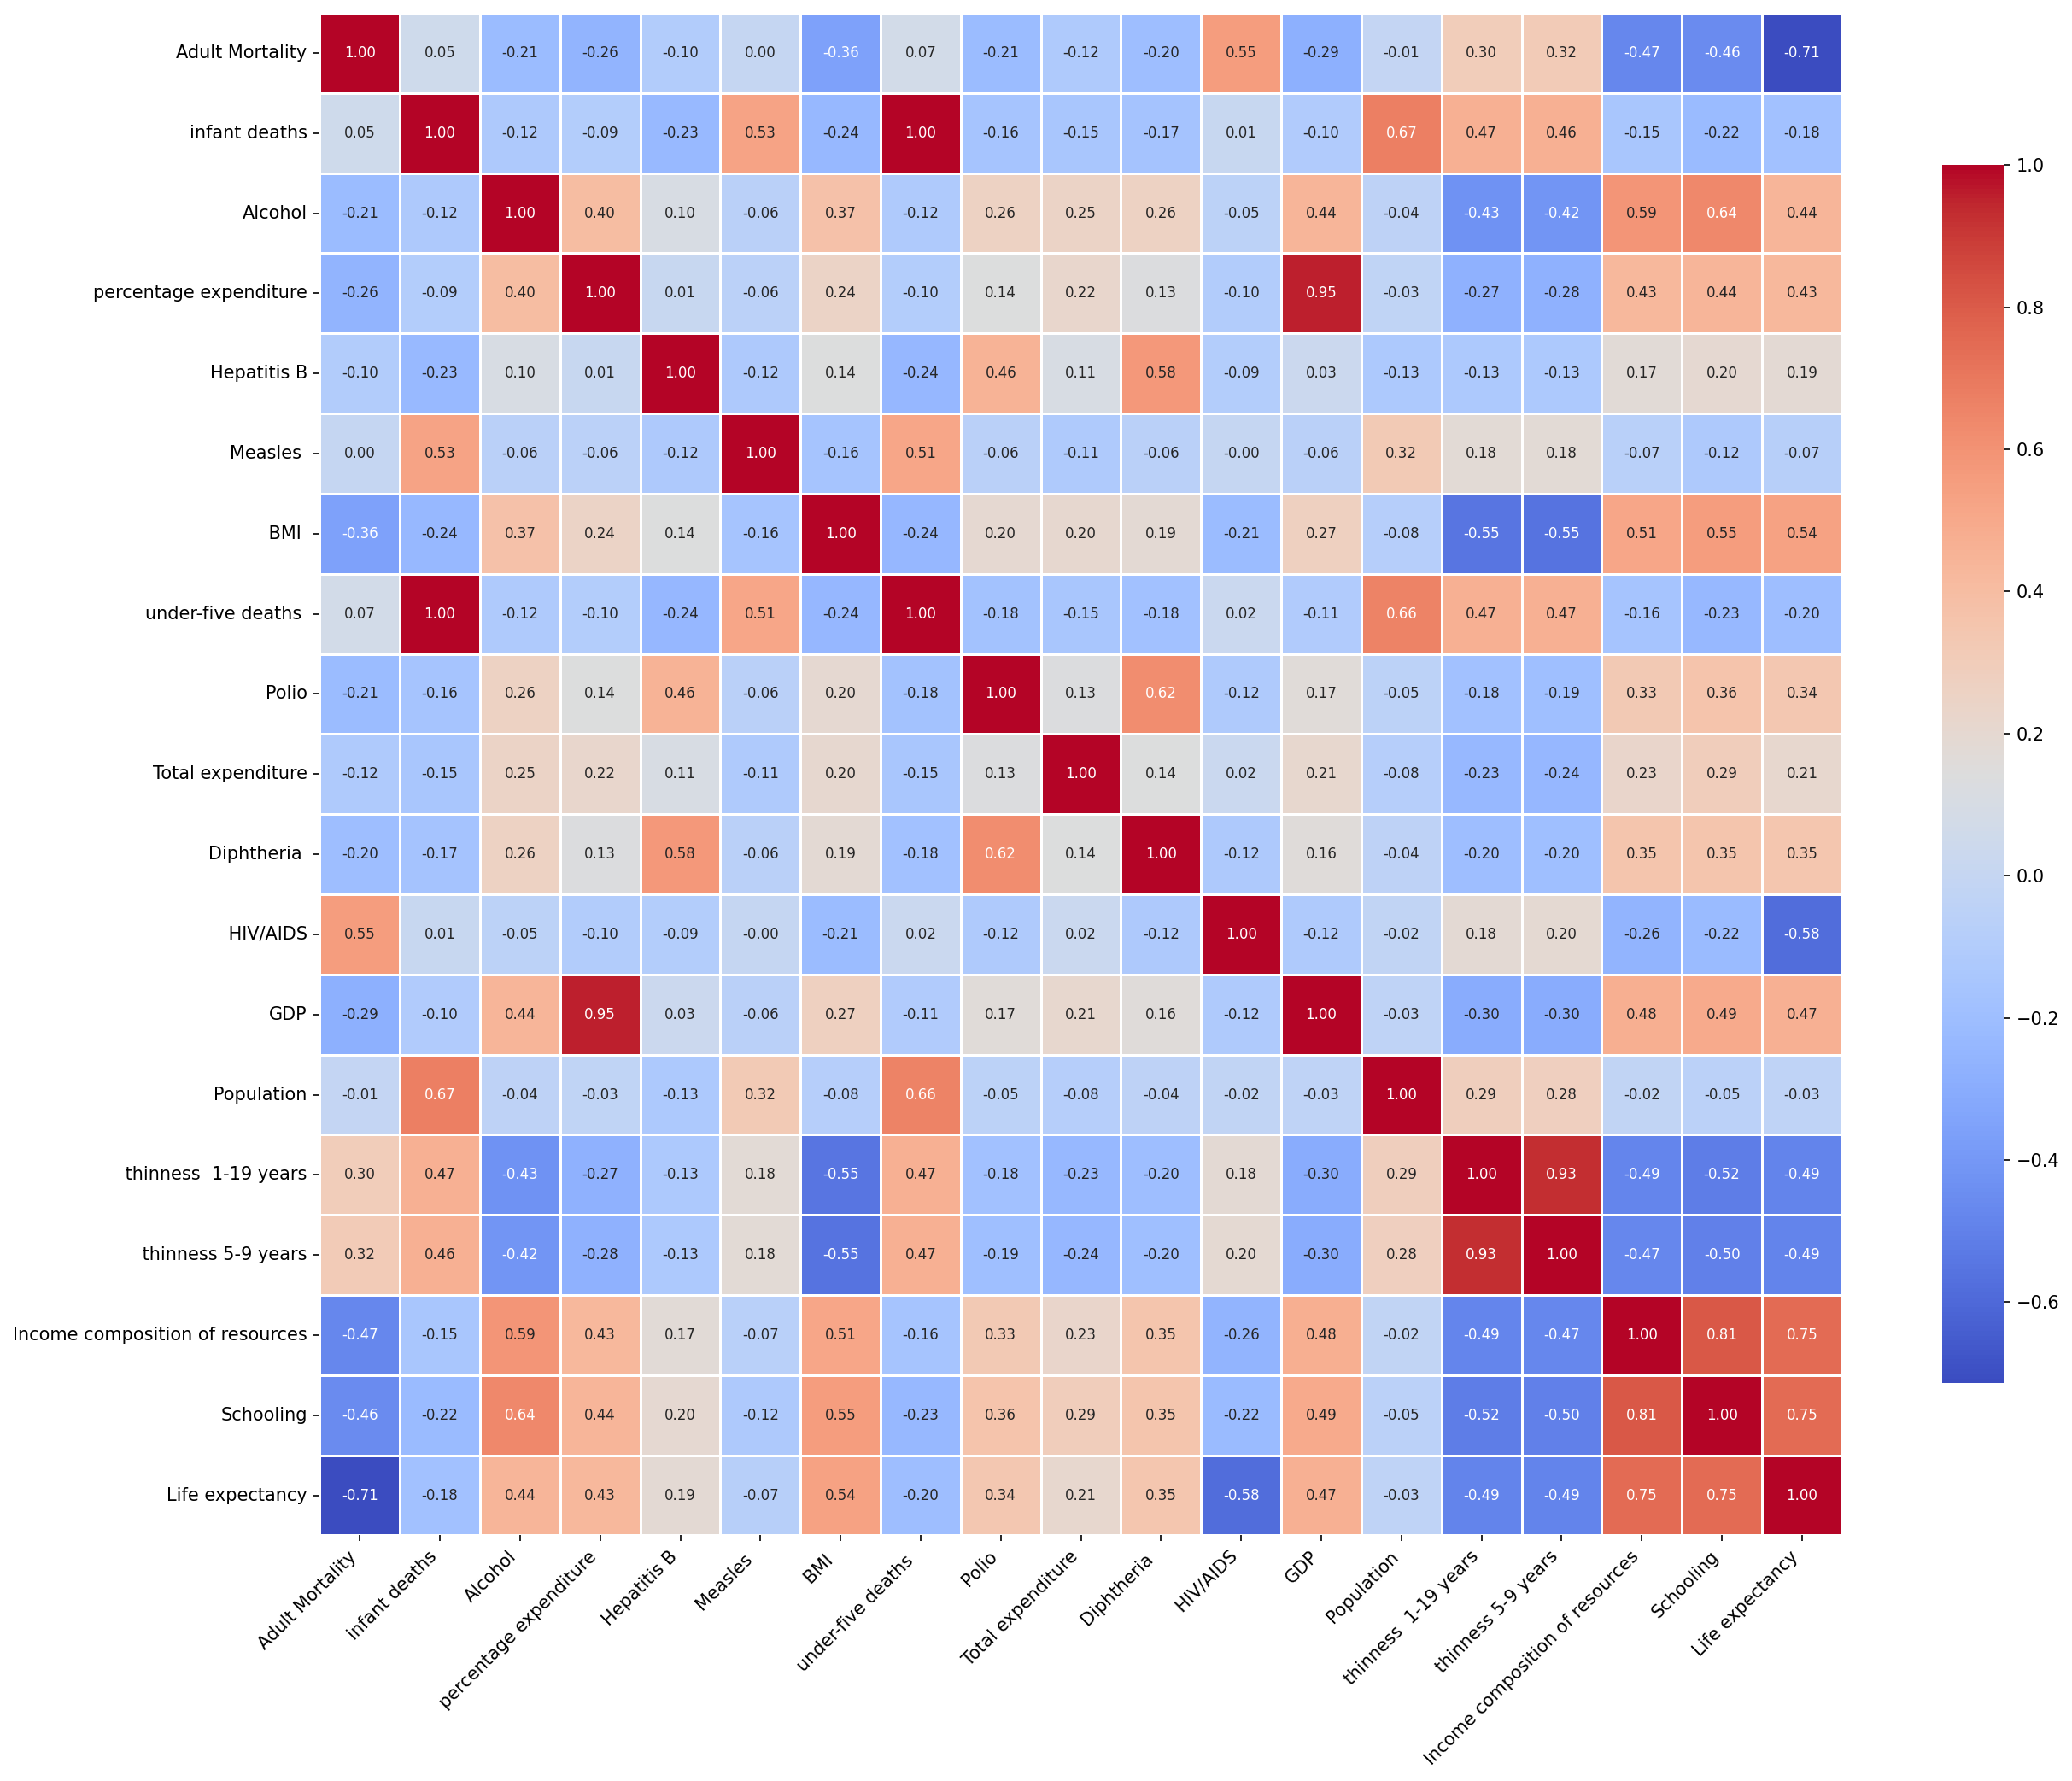

In [12]:

fig, ax = plt.subplots(figsize=(18, 14), dpi=150)
corr = df_vis.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5,
    annot_kws={"size": 8},
    cbar_kws={"shrink": 0.8},
    ax=ax
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### ساخت کپی برای مدیریت داده‌های گمشده

برای مرحله‌ی مدل‌سازی یک نسخه‌ی جدید با نام `df_mis` از داده‌ی اصلی ساخته می‌شود. این نسخه مستقل از `df_vis` است، چون در این بخش نمی‌خواهیم همه‌ی ردیف‌های دارای مقدار گمشده را حذف کنیم؛ در عوض تلاش می‌کنیم مقدارهای خالی را منطقی‌تر پر کنیم.


In [13]:
df_mis = df.copy()

### حذف ستون‌های کم‌استفاده

ستون‌های `Population` و `Measles ` از داده حذف می‌شوند. این ستون‌ها در این تحلیل برای مدل نهایی استفاده نشده‌اند و حذف آن‌ها باعث ساده‌تر شدن داده و کاهش مقدارهای گمشده یا نویز احتمالی می‌شود.


In [14]:
df_mis.drop(["Population" ,"Measles " ] , inplace=True , axis=1)

### نمایش داده‌های جدید

پس از حذف ستون‌های انتخاب‌شده، جدول `df_mis` نمایش داده می‌شود تا ساختار جدید داده بررسی شود و مطمئن شویم ستون‌های موردنظر با موفقیت حذف شده‌اند.


In [15]:
df_mis

,Country,Year,Status,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling,Life expectancy
0,Afghanistan,2015,Developing,263,62,0.01,71.279624,65.0,19.1,83,6.0,8.16,65,0.1,584.259210,17.2,17.3,0.479,10.1,65.0
1,Afghanistan,2014,Developing,271,64,0.01,73.523582,62.0,18.6,86,58.0,8.18,62,0.1,612.696514,17.5,17.5,0.476,10.0,59.9
2,Afghanistan,2013,Developing,268,66,0.01,73.219243,64.0,18.1,89,62.0,8.13,64,0.1,631.744976,17.7,17.7,0.470,9.9,59.9
3,Afghanistan,2012,Developing,272,69,0.01,78.184215,67.0,17.6,93,67.0,8.52,67,0.1,669.959000,17.9,18.0,0.463,9.8,59.5
4,Afghanistan,2011,Developing,275,71,0.01,7.097109,68.0,17.2,97,68.0,7.87,68,0.1,63.537231,18.2,18.2,0.454,9.5,59.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2231,Zimbabwe,2004,Developing,723,27,4.36,0.000000,68.0,27.1,42,67.0,7.13,65,33.6,454.366654,9.4,9.4,0.407,9.2,44.3
2232,Zimbabwe,2003,Developing,715,26,4.06,0.000000,7.0,26.7,41,7.0,6.52,68,36.7,453.351155,9.8,9.9,0.418,9.5,44.5
2233,Zimbabwe,2002,Developing,73,25,4.43,0.000000,73.0,26.3,40,73.0,6.53,71,39.8,57.348340,1.2,1.3,0.427,10.0,44.8
2234,Zimbabwe,2001,Developing,686,25,1.72,0.000000,76.0,25.9,39,76.0,6.16,75,42.1,548.587312,1.6,1.7,0.427,9.8,45.3


### بررسی مقادیر گمشده

در این مرحله دوباره تعداد مقدارهای گمشده محاسبه می‌شود، اما این بار روی داده‌ای که قرار است برای مدل‌سازی آماده شود. نتیجه‌ی این بررسی تعیین می‌کند کدام ستون‌ها باید با روش جایگزینی مقدار تکمیل شوند.


In [16]:
df_mis.isna().sum()

Country                              0
Year                                 0
Status                               0
Adult Mortality                      0
infant deaths                        0
Alcohol                            137
percentage expenditure               0
Hepatitis B                        329
 BMI                                 0
under-five deaths                    0
Polio                                8
Total expenditure                  140
Diphtheria                           0
 HIV/AIDS                            0
GDP                                 14
 thinness  1-19 years                0
 thinness 5-9 years                  0
Income composition of resources      0
Schooling                            0
Life expectancy                      0
dtype: int64

### پر کردن مقادیر گمشده با میانگین هر کشور

برای ستون‌های `Alcohol`، `Hepatitis B`، `Total expenditure`، `GDP` و `Polio` مقدارهای خالی با میانگین همان ستون در هر کشور جایگزین می‌شوند. این روش از میانگین کلی بهتر است، چون تفاوت‌های بین کشورها را تا حدی حفظ می‌کند.

ابتدا با `groupby("Country")` میانگین هر کشور محاسبه می‌شود و سپس با `fillna` فقط خانه‌های خالی پر می‌شوند.


In [17]:
Nan_dict = df_mis.groupby("Country")[["Alcohol" , "Hepatitis B" , "Total expenditure" , "GDP" , "Polio"]].transform("mean")



df_mis[["Alcohol" , "Hepatitis B" , "Total expenditure" , "GDP" , "Polio"]] = df_mis[["Alcohol" , "Hepatitis B" , "Total expenditure" , "GDP" , "Polio"]].fillna(Nan_dict)

### کنترل دوباره مقادیر گمشده پس از جایگزینی

بعد از پر کردن مقدارهای خالی، دوباره `isna().sum()` اجرا می‌شود تا مشخص شود هنوز ستون یا ردیفی با مقدار گمشده باقی مانده است یا نه. این کنترل قبل از آموزش مدل ضروری است، چون بیشتر مدل‌های `sklearn` با مقدارهای خالی کار نمی‌کنند.


In [18]:
df_mis.isna().sum()

Country                            0
Year                               0
Status                             0
Adult Mortality                    0
infant deaths                      0
Alcohol                            0
percentage expenditure             0
Hepatitis B                        0
 BMI                               0
under-five deaths                  0
Polio                              0
Total expenditure                  0
Diphtheria                         0
 HIV/AIDS                          0
GDP                                0
 thinness  1-19 years              0
 thinness 5-9 years                0
Income composition of resources    0
Schooling                          0
Life expectancy                    0
dtype: int64

### حذف ستون‌های شناسایی برای مدل‌سازی

ستون‌های `Country` و `Year` برای این مدل رگرسیونی حذف می‌شوند. هدف مدل پیش‌بینی امید به زندگی بر اساس شاخص‌های عددی و وضعیت توسعه است، نه حفظ شناسه‌ی کشور یا سال به صورت مستقیم.


In [19]:
df_mis.drop(["Country" , "Year"] , inplace=True , axis=1)
df_mis

,Status,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling,Life expectancy
0,Developing,263,62,0.01,71.279624,65.0,19.1,83,6.0,8.16,65,0.1,584.259210,17.2,17.3,0.479,10.1,65.0
1,Developing,271,64,0.01,73.523582,62.0,18.6,86,58.0,8.18,62,0.1,612.696514,17.5,17.5,0.476,10.0,59.9
2,Developing,268,66,0.01,73.219243,64.0,18.1,89,62.0,8.13,64,0.1,631.744976,17.7,17.7,0.470,9.9,59.9
3,Developing,272,69,0.01,78.184215,67.0,17.6,93,67.0,8.52,67,0.1,669.959000,17.9,18.0,0.463,9.8,59.5
4,Developing,275,71,0.01,7.097109,68.0,17.2,97,68.0,7.87,68,0.1,63.537231,18.2,18.2,0.454,9.5,59.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2231,Developing,723,27,4.36,0.000000,68.0,27.1,42,67.0,7.13,65,33.6,454.366654,9.4,9.4,0.407,9.2,44.3
2232,Developing,715,26,4.06,0.000000,7.0,26.7,41,7.0,6.52,68,36.7,453.351155,9.8,9.9,0.418,9.5,44.5
2233,Developing,73,25,4.43,0.000000,73.0,26.3,40,73.0,6.53,71,39.8,57.348340,1.2,1.3,0.427,10.0,44.8
2234,Developing,686,25,1.72,0.000000,76.0,25.9,39,76.0,6.16,75,42.1,548.587312,1.6,1.7,0.427,9.8,45.3


### تبدیل ستون وضعیت به مقدار عددی

ستون `Status` مقدارهای متنی `Developing` و `Developed` دارد. برای استفاده در مدل‌های رگرسیونی، این مقدارها به عدد تبدیل می‌شوند تا مدل بتواند آن‌ها را به عنوان یک ویژگی ورودی پردازش کند.


In [20]:
df_mis["Status"] = df_mis["Status"].replace(["Developing" , "Developed"] , [2 , 3])
df_mis

,Status,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling,Life expectancy
0,2,263,62,0.01,71.279624,65.0,19.1,83,6.0,8.16,65,0.1,584.259210,17.2,17.3,0.479,10.1,65.0
1,2,271,64,0.01,73.523582,62.0,18.6,86,58.0,8.18,62,0.1,612.696514,17.5,17.5,0.476,10.0,59.9
2,2,268,66,0.01,73.219243,64.0,18.1,89,62.0,8.13,64,0.1,631.744976,17.7,17.7,0.470,9.9,59.9
3,2,272,69,0.01,78.184215,67.0,17.6,93,67.0,8.52,67,0.1,669.959000,17.9,18.0,0.463,9.8,59.5
4,2,275,71,0.01,7.097109,68.0,17.2,97,68.0,7.87,68,0.1,63.537231,18.2,18.2,0.454,9.5,59.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2231,2,723,27,4.36,0.000000,68.0,27.1,42,67.0,7.13,65,33.6,454.366654,9.4,9.4,0.407,9.2,44.3
2232,2,715,26,4.06,0.000000,7.0,26.7,41,7.0,6.52,68,36.7,453.351155,9.8,9.9,0.418,9.5,44.5
2233,2,73,25,4.43,0.000000,73.0,26.3,40,73.0,6.53,71,39.8,57.348340,1.2,1.3,0.427,10.0,44.8
2234,2,686,25,1.72,0.000000,76.0,25.9,39,76.0,6.16,75,42.1,548.587312,1.6,1.7,0.427,9.8,45.3


### بررسی نام ستون‌های داده‌ی اصلی

در این سلول نام ستون‌های دیتافریم اصلی نمایش داده می‌شود. این کار برای مقایسه با نسخه‌ی آماده‌سازی‌شده و کنترل اینکه چه ستون‌هایی حذف یا تبدیل شده‌اند مفید است.


In [21]:
df.columns

Index(['Country', 'Year', 'Status', 'Adult Mortality', 'infant deaths',
       'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles ', ' BMI ',
       'under-five deaths ', 'Polio', 'Total expenditure', 'Diphtheria ',
       ' HIV/AIDS', 'GDP', 'Population', ' thinness  1-19 years',
       ' thinness 5-9 years', 'Income composition of resources', 'Schooling',
       'Life expectancy'],
      dtype='str')

### جداسازی ویژگی‌ها و متغیر هدف

در این مرحله داده به دو بخش تقسیم می‌شود:

- `x`: همه‌ی ستون‌ها به جز `Life expectancy` به عنوان ویژگی‌های ورودی
- `y`: ستون `Life expectancy` به عنوان مقدار هدفی که مدل باید پیش‌بینی کند


In [22]:
x = df_mis.iloc[: , df_mis.columns != "Life expectancy"]
y = df_mis["Life expectancy"]

### تقسیم داده به آموزش، اعتبارسنجی و آزمون

ابتدا ۲۰ درصد داده جدا می‌شود و سپس همان بخش به دو قسمت اعتبارسنجی و آزمون تقسیم می‌گردد. در نتیجه داده‌ها به سه بخش اصلی تبدیل می‌شوند:

- داده‌ی آموزش برای یادگیری مدل
- داده‌ی اعتبارسنجی برای بررسی عملکرد هنگام تنظیم مدل
- داده‌ی آزمون برای ارزیابی نهایی روی داده‌های دیده‌نشده

استفاده از `random_state=0` باعث می‌شود تقسیم داده در اجراهای مختلف تکرارپذیر باشد.


In [23]:
x_train , x_test , y_train , y_test = tts(x , y , test_size= 0.2 , random_state= 0)

x_val , x_test , y_val , y_test = tts(x_test , y_test , test_size=0.5 , random_state= 0)

### آموزش مدل رگرسیون خطی ساده

یک مدل `LinearRegression` ساخته و روی داده‌های آموزشی آموزش داده می‌شود. این مدل تلاش می‌کند رابطه‌ی خطی بین ویژگی‌ها و امید به زندگی را یاد بگیرد.


In [24]:
model1 = LinearRegression()

model1.fit(x_train , y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### ارزیابی امتیاز مدل خطی

تابع `score` برای رگرسیون مقدار `R²` را برمی‌گرداند. این معیار نشان می‌دهد مدل چه مقدار از تغییرات متغیر هدف را توضیح می‌دهد. مقایسه‌ی امتیاز آموزش، اعتبارسنجی و آزمون کمک می‌کند بیش‌برازش یا کم‌برازش مدل تشخیص داده شود.


In [25]:
print(model1.score(x_train , y_train))
print(model1.score(x_val , y_val))
print(model1.score(x_test , y_test))

0.8489002523400795
0.8432293738680385
0.8097200207881157


### محاسبه خطای مطلق میانگین

پس از پیش‌بینی مقدارهای آزمون، معیار `mean_absolute_error` محاسبه می‌شود. این معیار میانگین قدر مطلق اختلاف بین مقدار واقعی و مقدار پیش‌بینی‌شده را نشان می‌دهد و واحد آن همان واحد امید به زندگی است.


In [26]:
y_pred = model1.predict(x_test)
mean_absolute_error(y_test , y_pred)

2.9389179864554316

### ساخت ویژگی‌های چندجمله‌ای

برای ثبت رابطه‌های غیرخطی بین متغیرها، از `PolynomialFeatures` استفاده می‌شود. با درجه‌ی ۲، علاوه بر ویژگی‌های اصلی، توان دوم و ترکیب‌های دوتایی ویژگی‌ها هم ساخته می‌شوند.

این کار می‌تواند قدرت مدل را بیشتر کند، اما تعداد ویژگی‌ها را هم افزایش می‌دهد و احتمال بیش‌برازش را بالا می‌برد.


In [27]:
poly = PolynomialFeatures(degree=(1,2) , interaction_only=False , include_bias=False)

x_poly = poly.fit_transform(x)

x_train_poly  , x_test_poly , y_train_poly , y_test_poly = tts(x_poly , y , test_size=0.2 , random_state=0)


### آموزش رگرسیون خطی روی ویژگی‌های چندجمله‌ای

در این بخش یک مدل خطی جدید روی ویژگی‌های چندجمله‌ای آموزش داده می‌شود. اگر رابطه‌ی بین شاخص‌ها و امید به زندگی کاملاً خطی نباشد، این مدل می‌تواند الگوهای پیچیده‌تری را نسبت به رگرسیون خطی ساده یاد بگیرد.


In [28]:
model2 = LinearRegression()

model2.fit(x_train_poly , y_train_poly)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### بررسی امتیاز مدل چندجمله‌ای

امتیاز `R²` مدل چندجمله‌ای روی داده‌ی آزمون محاسبه می‌شود. این مقدار با امتیاز مدل خطی ساده قابل مقایسه است و نشان می‌دهد اضافه کردن ویژگی‌های درجه‌ی ۲ چقدر عملکرد مدل را بهتر یا بدتر کرده است.


In [29]:
model2.score(x_test_poly , y_test_poly)

0.9081664282320675

### محاسبه R² با پیش‌بینی‌های مدل چندجمله‌ای

در این سلول ابتدا مقدارهای آزمون با مدل چندجمله‌ای پیش‌بینی می‌شوند و سپس `r2_score` محاسبه می‌شود. این کار همان معیار `R²` را به صورت مستقیم از روی مقدارهای واقعی و پیش‌بینی‌شده به دست می‌آورد.


In [30]:
y_poly_pred = model2.predict(x_test_poly)

r2_score(y_test_poly , y_poly_pred)

0.9081664282320675

### وارد کردن مدل‌های منظم‌سازی

مدل‌های `Ridge` و `Lasso` از خانواده‌ی رگرسیون‌های منظم‌سازی‌شده هستند. این مدل‌ها برای کنترل پیچیدگی مدل و کاهش بیش‌برازش، به ضرایب مدل جریمه اضافه می‌کنند.


In [31]:
from sklearn.linear_model import Ridge , Lasso

### آموزش مدل Ridge

مدل `Ridge` با مقدار `alpha=2` آموزش داده می‌شود. این مدل از جریمه‌ی L2 استفاده می‌کند و معمولاً وقتی تعداد ویژگی‌ها زیاد است، مثل حالت چندجمله‌ای، می‌تواند مدل را پایدارتر کند.


In [32]:
model3 = Ridge(alpha=2)

model3.fit(x_train_poly , y_train_poly)

c:\Users\Mahdi\anaconda3\envs\pythoncontinue\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 8.906450465591605e-22.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",2
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


### ارزیابی مدل Ridge

امتیاز `R²` مدل Ridge روی داده‌ی آزمون محاسبه می‌شود. با مقایسه‌ی این امتیاز با مدل چندجمله‌ای بدون منظم‌سازی می‌توان فهمید جریمه‌ی L2 به بهبود تعمیم‌پذیری مدل کمک کرده است یا نه.


In [33]:
model3.score(x_test_poly , y_test_poly)

0.8953017803869268

### مقایسه چند مقدار alpha در Ridge

در این حلقه چند مقدار مختلف برای `alpha` آزمایش می‌شود. مقدار کوچک‌تر یعنی جریمه‌ی ضعیف‌تر و مقدار بزرگ‌تر یعنی جریمه‌ی قوی‌تر. هدف این است که ببینیم کدام مقدار تعادل بهتری بین یادگیری و جلوگیری از بیش‌برازش ایجاد می‌کند.


In [34]:
for a in [0.01, 0.1, 1, 2, 5, 10]:
    model = Ridge(alpha=a)
    model.fit(x_train_poly, y_train_poly)
    print(a, model.score(x_test_poly, y_test_poly))

0.01 0.9079815021307265
0.1 0.9066365364026434
1 0.8985569605081687
2 0.8953017803869268
5 0.8923085928697094
10 0.8911199994968987


c:\Users\Mahdi\anaconda3\envs\pythoncontinue\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 4.474325474532524e-24.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\Mahdi\anaconda3\envs\pythoncontinue\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 4.4722503815566447e-23.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\Mahdi\anaconda3\envs\pythoncontinue\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 4.4606882848225625e-22.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\Mahdi\anaconda3\envs\pythoncontinue\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 8.906450465591605e-22.
  return linalg.solve(A, Xy, as

### آموزش مدل Lasso

مدل `Lasso` با مقدار `alpha=2` آموزش داده می‌شود. این مدل از جریمه‌ی L1 استفاده می‌کند و می‌تواند برخی ضرایب را دقیقاً صفر کند؛ بنابراین گاهی نقش انتخاب ویژگی را هم دارد.


In [35]:
model4 = Lasso(alpha=2)

model4.fit(x_train_poly , y_train_poly)

c:\Users\Mahdi\anaconda3\envs\pythoncontinue\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.075e+03, tolerance: 1.737e+01
  model = cd_fast.enet_coordinate_descent(


,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",2
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


### ارزیابی مدل Lasso

در این سلول امتیاز `R²` مدل Lasso روی داده‌ی آزمون محاسبه می‌شود. اگر امتیاز نسبت به Ridge یا مدل چندجمله‌ای پایین‌تر باشد، ممکن است مقدار `alpha` بیش از حد بزرگ باشد یا حذف ضرایب به عملکرد مدل آسیب زده باشد.


In [36]:
model4.score(x_test_poly , y_test_poly)

0.8810442676450361

### رسم مقایسه مقدارهای واقعی و پیش‌بینی‌شده

در این نمودار مقدارهای پیش‌بینی‌شده در برابر مقدارهای واقعی رسم می‌شوند. خط قرمز حالت ایده‌آل را نشان می‌دهد؛ هرچه نقاط آبی به این خط نزدیک‌تر باشند، پیش‌بینی مدل دقیق‌تر است.


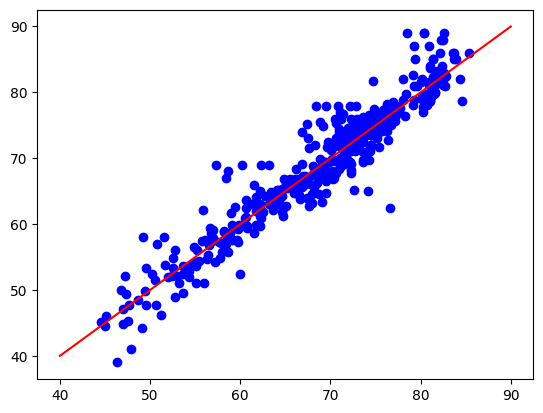

In [37]:
plt.scatter(y_poly_pred , y_test_poly , color = "blue")
plt.plot([40 , 90] , [40 , 90] , color = "red")
plt.show()

### رسم نمودار نهایی با برچسب و راهنما

این نسخه همان مقایسه‌ی مقدارهای واقعی و پیش‌بینی‌شده را با عنوان، برچسب محور، راهنما و شبکه نمایش می‌دهد. این شکل برای ارائه‌ی نتیجه‌ی مدل خواناتر از نمودار ساده‌ی قبلی است.


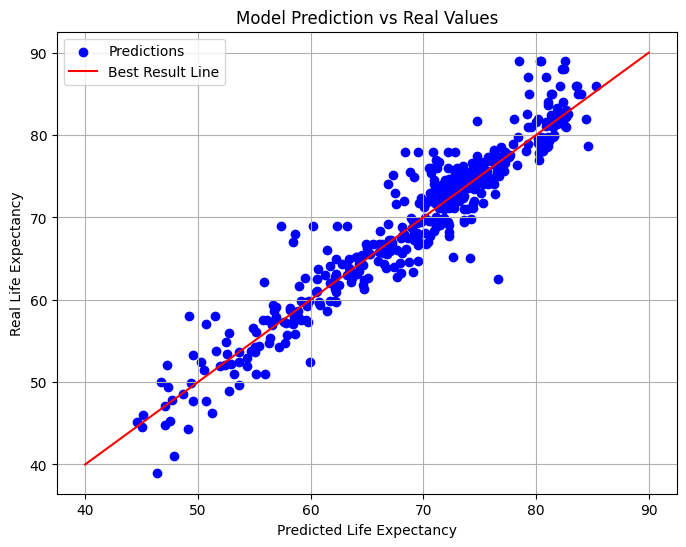

In [38]:
plt.figure(figsize=(8, 6))

plt.scatter(y_poly_pred, y_test_poly, color="blue", label="Predictions")

plt.plot([40, 90], [40, 90], color="red", label="Best Result Line")

plt.xlabel("Predicted Life Expectancy")
plt.ylabel("Real Life Expectancy")
plt.title("Model Prediction vs Real Values")

plt.legend()
plt.grid(True)

plt.show()

### آموزش نهایی مدل منتخب روی کل داده

پس از ارزیابی مدل‌ها، مدل چندجمله‌ای دوباره روی کل داده‌ی موجود آموزش داده می‌شود. این کار زمانی انجام می‌شود که مدل انتخاب شده و می‌خواهیم از تمام داده برای یادگیری نهایی استفاده کنیم.


In [39]:
model2.fit(x_poly , y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### بررسی امتیاز مدل روی کل داده

امتیاز مدل روی تمام داده محاسبه می‌شود. این عدد برای فهمیدن میزان برازش مدل روی داده‌ی موجود مفید است، اما جایگزین ارزیابی روی داده‌ی آزمون نیست، چون مدل همین داده‌ها را در مرحله‌ی آموزش دیده است.


In [40]:
model2.score(x_poly , y)

0.940988006200536

### آزمایش مدل روی یک نمونه تصادفی

یک ردیف تصادفی از داده انتخاب می‌شود، همان تبدیل چندجمله‌ای روی آن اعمال می‌شود و سپس مدل مقدار امید به زندگی را پیش‌بینی می‌کند. در پایان مقدار پیش‌بینی‌شده و مقدار واقعی کنار هم نمایش داده می‌شوند تا خروجی مدل به صورت نمونه‌ای قابل بررسی باشد.


In [41]:
sample_data = x.sample(random_state=87)

sample_data_trans = poly.transform(sample_data)

res = pd.DataFrame({
    "pred": model2.predict(sample_data_trans),
    "real": y[sample_data.index]
})

print(res)

           pred  real
1526  53.797961  53.7


### پایان تحلیل

در این نوت‌بوک داده‌های امید به زندگی از مرحله‌ی بررسی اولیه تا آموزش و ارزیابی چند مدل رگرسیونی تحلیل شدند. مسیر انجام‌شده نشان می‌دهد که آماده‌سازی داده، مدیریت مقدارهای گمشده، بررسی رابطه‌ها و انتخاب مدل همگی روی کیفیت پیش‌بینی اثر مستقیم دارند.
